## ThinkDSP

This notebook contains code examples from Chapter 3: Non-periodic signals

Copyright 2015 Allen Downey

License: [Creative Commons Attribution 4.0 International](http://creativecommons.org/licenses/by/4.0/)

In [1]:
# Get thinkdsp.py

import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py

--2025-05-25 19:44:19--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py [following]
--2025-05-25 19:44:19--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/thinkdsp.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 48554 (47K) [text/plain]
Saving to: ‘thinkdsp.py’

thinkdsp.py         100%[===================>]  47.42K  --.-KB/s    in 0.05s   

2025-05-25 19:44:20 (1015 KB/s) - ‘thinkdsp.py’ saved [48554/48554]



In [2]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

### Chirp

Make a linear chirp from A3 to A5.

In [3]:
from thinkdsp import Chirp

signal = Chirp(start=220, end=880)
wave1 = signal.make_wave(duration=2)
wave1.make_audio()

Here's what the waveform looks like near the beginning.

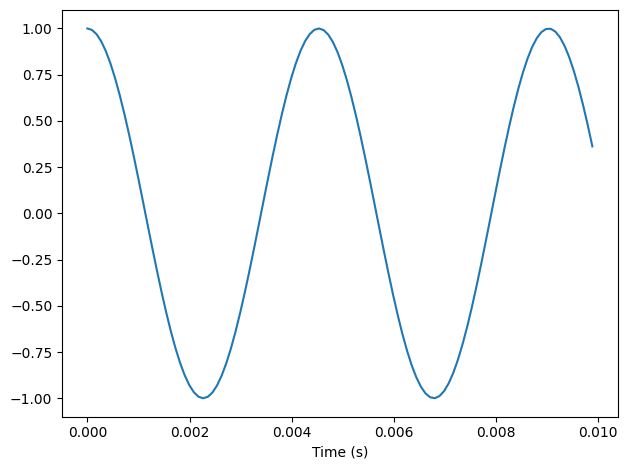

In [4]:
wave1.segment(start=0, duration=0.01).plot()
decorate(xlabel='Time (s)')

And near the end.

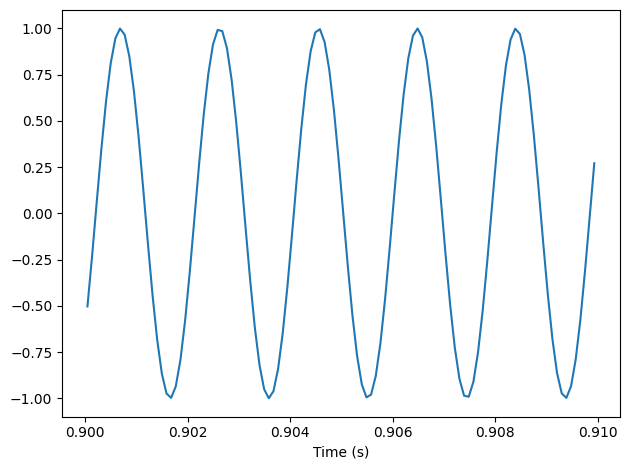

In [5]:
wave1.segment(start=0.9, duration=0.01).plot()
decorate(xlabel='Time (s)')

Here's an exponential chirp with the same frequency range and duration.

In [6]:
from thinkdsp import ExpoChirp

signal = ExpoChirp(start=220, end=880)
wave2 = signal.make_wave(duration=2)
wave2.make_audio()

## Leakage

Spectral leakage is when some of the energy at one frequency appears at another frequency (usually nearby).

Let's look at the effect of leakage on a sine signal (which only contains one frequency component).

In [7]:
from thinkdsp import SinSignal

signal = SinSignal(freq=440)

If the duration is an integer multiple of the period, the beginning and end of the segment line up, and we get minimal leakage.

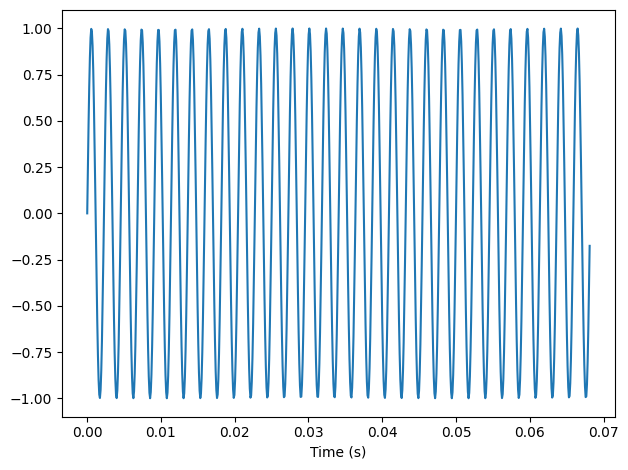

In [8]:
duration = signal.period * 30
wave = signal.make_wave(duration)
wave.plot()
decorate(xlabel='Time (s)')

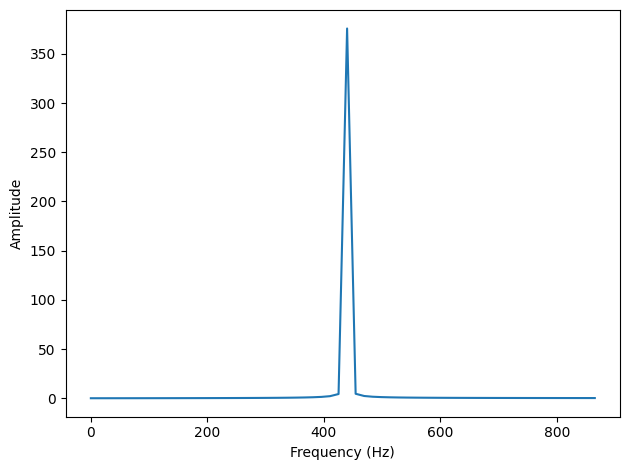

In [9]:
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

If the duration is not a multiple of a period, the leakage is pretty bad.

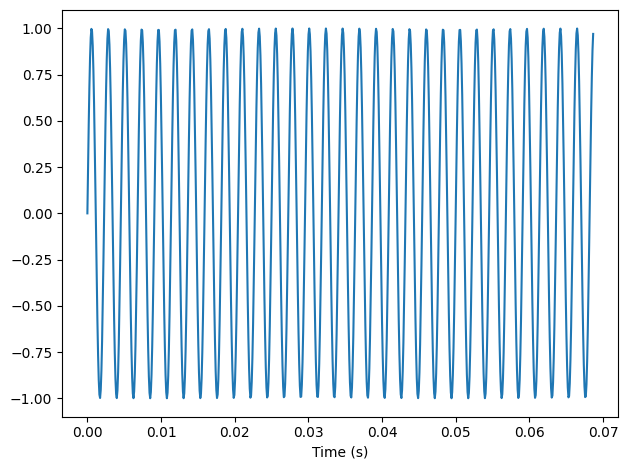

In [10]:
duration = signal.period * 30.25
wave = signal.make_wave(duration)
wave.plot()
decorate(xlabel='Time (s)')

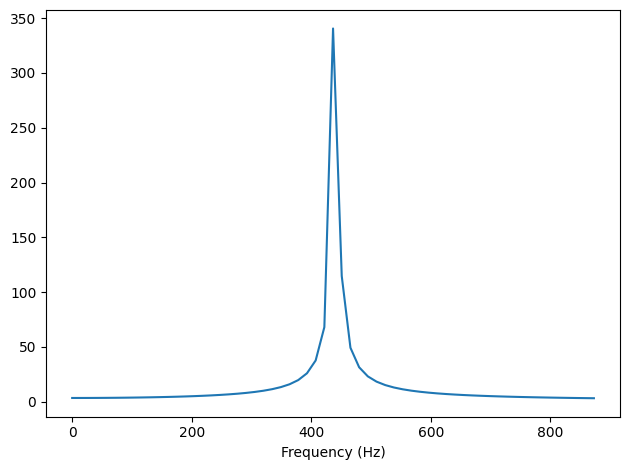

In [11]:
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)')

Windowing helps (but notice that it reduces the total energy).

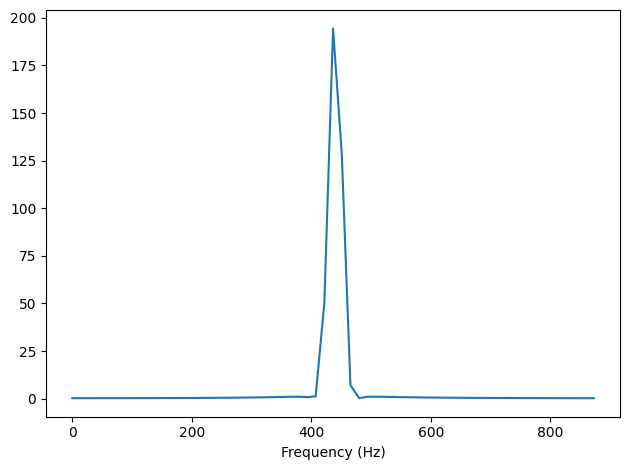

In [12]:
wave.hamming()
spectrum = wave.make_spectrum()
spectrum.plot(high=880)
decorate(xlabel='Frequency (Hz)')

## Spectrogram

If you blindly compute the DFT of a non-periodic segment, you get "motion blur".

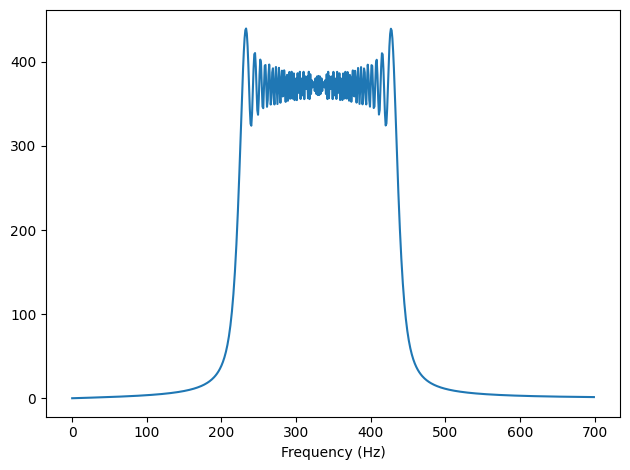

In [13]:
signal = Chirp(start=220, end=440)
wave = signal.make_wave(duration=1)
spectrum = wave.make_spectrum()
spectrum.plot(high=700)
decorate(xlabel='Frequency (Hz)')

A spectrogram is a visualization of a short-time DFT that lets you see how the spectrum varies over time.

In [14]:
def plot_spectrogram(wave, seg_length):
    """
    """
    spectrogram = wave.make_spectrogram(seg_length)
    print('Time resolution (s)', spectrogram.time_res)
    print('Frequency resolution (Hz)', spectrogram.freq_res)
    spectrogram.plot(high=700)
    decorate(xlabel='Time(s)', ylabel='Frequency (Hz)')

Time resolution (s) 0.046439909297052155
Frequency resolution (Hz) 21.533203125


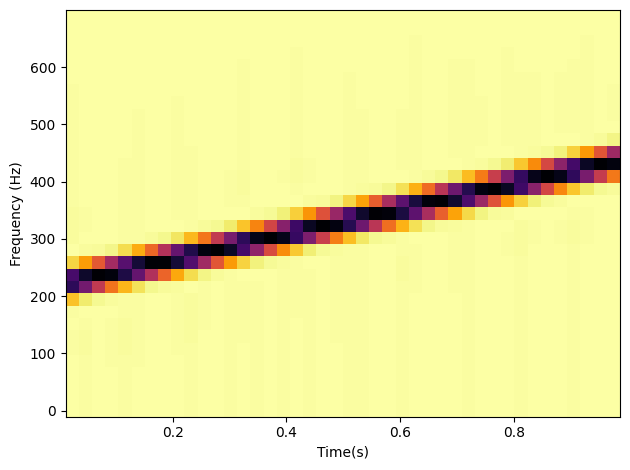

In [15]:
signal = Chirp(start=220, end=440)
wave = signal.make_wave(duration=1, framerate=11025)
plot_spectrogram(wave, 512)

If you increase the segment length, you get better frequency resolution, worse time resolution.

Time resolution (s) 0.09287981859410431
Frequency resolution (Hz) 10.7666015625


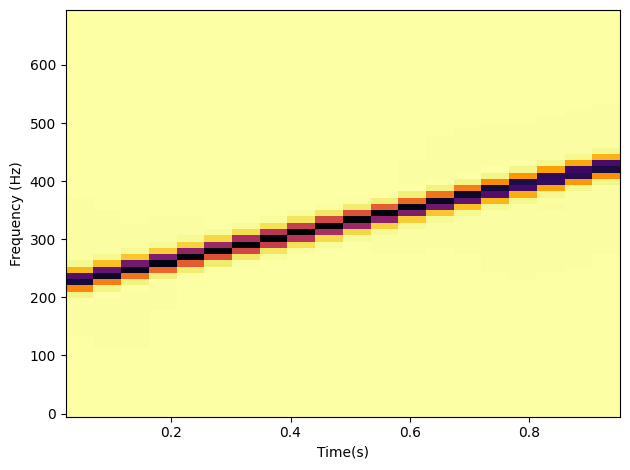

In [16]:
plot_spectrogram(wave, 1024)

If you decrease the segment length, you get better time resolution, worse frequency resolution.

Time resolution (s) 0.023219954648526078
Frequency resolution (Hz) 43.06640625


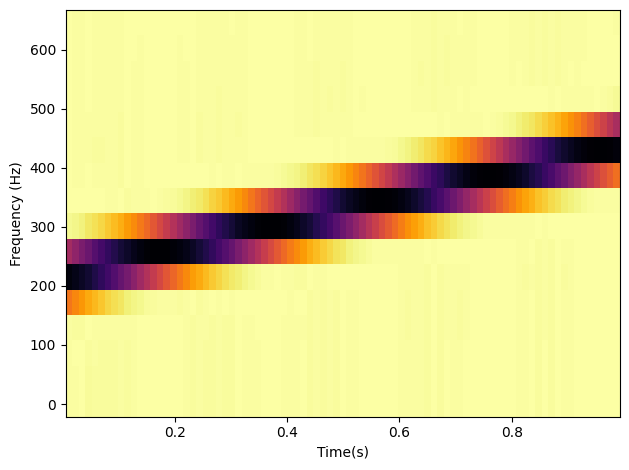

In [17]:
plot_spectrogram(wave, 256)

In [18]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider = widgets.IntSlider(min=128, max=4096, value=100, step=128)
interact(plot_spectrogram, wave=fixed(wave), seg_length=slider);

interactive(children=(IntSlider(value=128, description='seg_length', max=4096, min=128, step=128), Output()), …

## Spectrum of a chirp

The following interaction lets you customize the Eye of Sauron as you vary the start and end frequency of the chirp.

In [19]:
def eye_of_sauron(start, end):
    """Plots the spectrum of a chirp.

    start: initial frequency
    end: final frequency
    """
    signal =  Chirp(start=start, end=end)
    wave = signal.make_wave(duration=0.5)
    spectrum = wave.make_spectrum()

    spectrum.plot(high=1200)
    decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

In [20]:
slider1 = widgets.FloatSlider(min=100, max=1000, value=100, step=50)
slider2 = widgets.FloatSlider(min=100, max=1000, value=200, step=50)
interact(eye_of_sauron, start=slider1, end=slider2);

interactive(children=(FloatSlider(value=100.0, description='start', max=1000.0, min=100.0, step=50.0), FloatSl…

# **Упражнение 3.1**
Запустите и прослушайте примеры из блокнота chap03.ipynb.
B примере с утечкой замените окно Хэмминга одним из окон, предоставляемых NumPy, и посмотрите, как они влияют нa утечку.

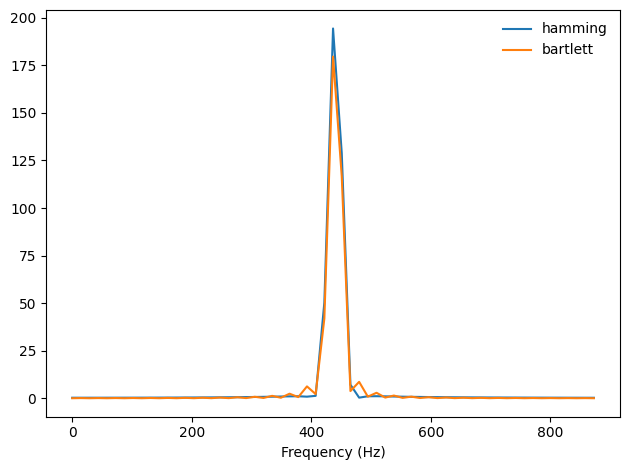

In [22]:
signal = SinSignal(freq=440)
duration = signal.period * 30.25
wave = signal.make_wave(duration)
wave.hamming()
spectrum = wave.make_spectrum()
spectrum.plot(high=880, label=wave.hamming.__name__)


wave = signal.make_wave(duration)
wave.ys *= np.bartlett(len(wave.ys))
spectrum = wave.make_spectrum()
spectrum.plot(high=880, label=np.bartlett.__name__)

decorate(xlabel='Frequency (Hz)')

Окно Хэмминга и окно Бартлетта довольно похожи, но у окна Бартлетта есть остаточный "звон" (ломаные внизу пика).

# **Упражнение 3.2**
Напишите класс, называемый SawtoothChirp, расширяющий
Chirp и переопределяющий evaluate для генерации пилообразного сигнала с линейно увеличивающейся (или уменьшающейся) частотой.

Подсказка: надо совместить Функции evaluate Из Chirp И
SawtoothSignal.

Нарисуйте эскиз спектрограммы этого сигнала, a затем распечатайте ее. Эффект биений должен быть очевиден, а если сигнал внимательно прослушать, то биения можно и услышать.


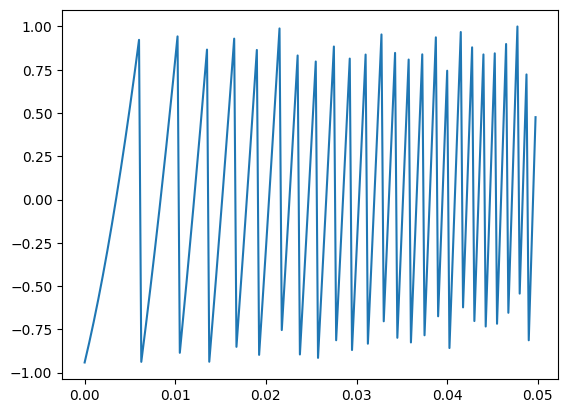

In [23]:
from thinkdsp import normalize, unbias

PI2 = 2 * np.pi

class SawtoothChirp(Chirp):
    def evaluate(self, ts):
        freqs = np.linspace(self.start, self.end, len(ts))
        dts = np.diff(ts, prepend=0)
        dphis = 2 * np.pi * freqs * dts
        phases = np.cumsum(dphis)
        cycles = phases / (2 * np.pi)
        frac, _ = np.modf(cycles)
        ys = self.amp * normalize(unbias(frac))
        return ys

chirp = SawtoothChirp(start=110, end=880)
chirp_wave = chirp.make_wave(duration=0.05, framerate=4000)
chirp_wave.plot()

In [26]:
chirp_wave1 = chirp.make_wave(duration=1, framerate=4000)
chirp_wave1.apodize()
chirp_wave1.make_audio()

Биения действительно слышны при прослушивании, начало резкое.

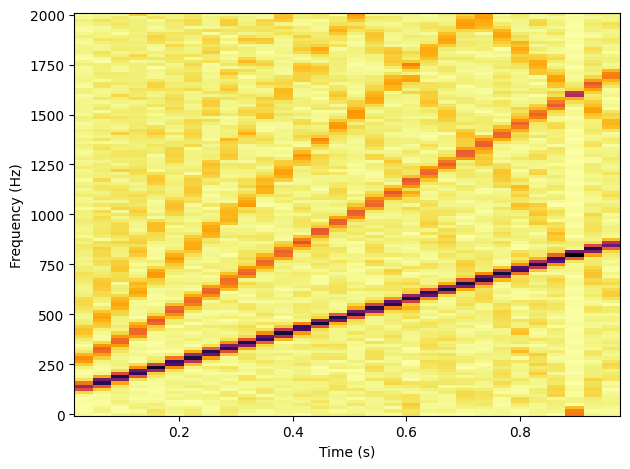

In [27]:
sp = chirp_wave1.make_spectrogram(256)
sp.plot()
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

Гармоники пилообразного чирпа не параллельны, а расходятся веером из-за линейного роста основной частоты и умножения гармоник на n, что делает их наклон зависимым от номера гармоники. А биения выглядят как волны или зигзаги вдоль линий гармоник. Это происходит за счет того, что когда гармоники приближаются к частоте сгибания, они "отражаются" назад, создавая зеркальные копии и эти отраженные гармоники интерферируют с основными.

# **Упражнение 3.3**
Создайте пилообразный чирп, меняющийся от 2500 до 3000 Гц, и на его основе сгенерируйте сигнал длительностью 1 с и частотой кадров 20 кГц. Нарисуйте, каким примерно будет Spectrum. Затем распечатайте Spectrum и посмотрите, правы ли вы.

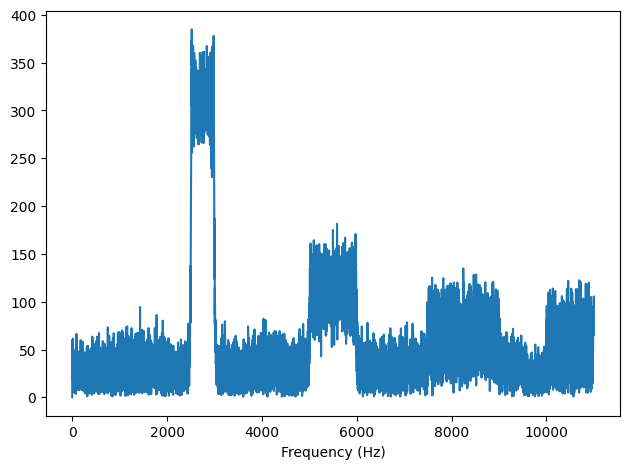

In [28]:
sawtooth_chirp = SawtoothChirp(start=2500, end=3000)
sawtooth_chirp_wave = sawtooth_chirp.make_wave(duration=1, framerate=22000)
sawtooth_chirp_wave.make_spectrum().plot()
decorate(xlabel='Frequency (Hz)')

# **Задание 3.4.**
В музыкальной терминологии глиссандо — это нота, меняющаяся от одной высоты до другой, то есть своеобразный чирп.

Найдите или запишите звук глиссандо и распечатайте спектрограмму первых нескольких секунд.


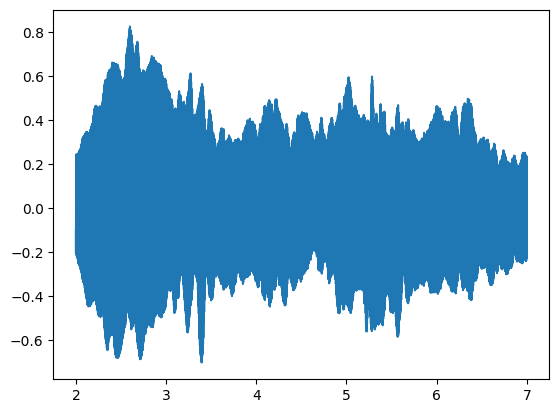

In [41]:
from thinkdsp import read_wave
filename = "glissando.wav"
gliss_wave = read_wave(filename)
start = 2
length = 5
segment_gliss = gliss_wave.segment(start, length)
segment_gliss.plot()

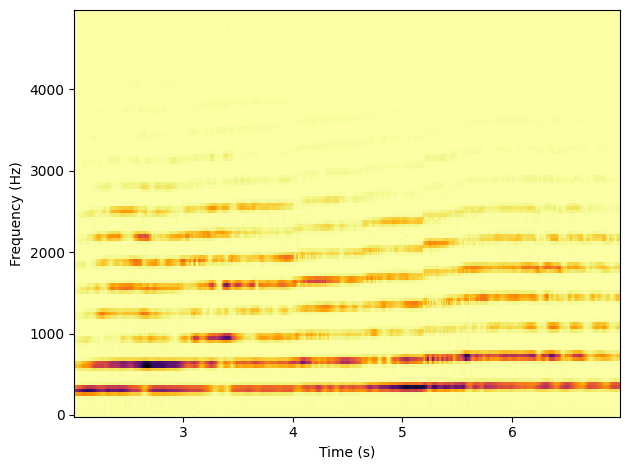

In [35]:
spp = segment_gliss.make_spectrogram(1024)
spp.plot(high=5000)
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

# **Упражнение 3.5**

Тромбонист играет глиссандо, непрерывно дуя в мундштук и двигая кулису тромбона. При этом общая длина трубы меняется, а играемая нота обратно пропорциональна этой длине.

Если предположить, что музыкант двигает кулису с постоянной скоростью, как будет меняться во времени частота?

Напишите класс, называемый TromboneGliss, расширяющий
Chirp и предоставляющий evaluate. Создайте сигнал, имитирующий глиссандо на тромбоне от C3 до F3, и обратно до C3. СЗ — 262 Гц; F3 — 349 Гц.
Напечатайте спектрограмму полученного сигнала. На что похоже глиссандо на тромбоне — на линейный или же экспоненциальный чирп?


In [36]:
class TromboneGliss(Chirp):
    def evaluate(self, ts):
        l1, l2 = 1.0 / self.start, 1.0 / self.end
        lengths = np.linspace(l1, l2, len(ts))
        freqs = 1 / lengths

        dts = np.diff(ts, prepend=0)
        dphis = 2 * np.pi * freqs * dts
        phases = np.cumsum(dphis)
        ys = self.amp * np.cos(phases)
        return ys
low = 262
high = 349
signal = TromboneGliss(high, low)
Trombone1 = signal.make_wave(duration=2)
Trombone1.apodize()

signal = TromboneGliss(low, high)
Trombone2 = signal.make_wave(duration=2)
Trombone2.apodize()

Trombone = Trombone1 | Trombone2
Trombone.write("Trombone.wav")

Writing Trombone.wav


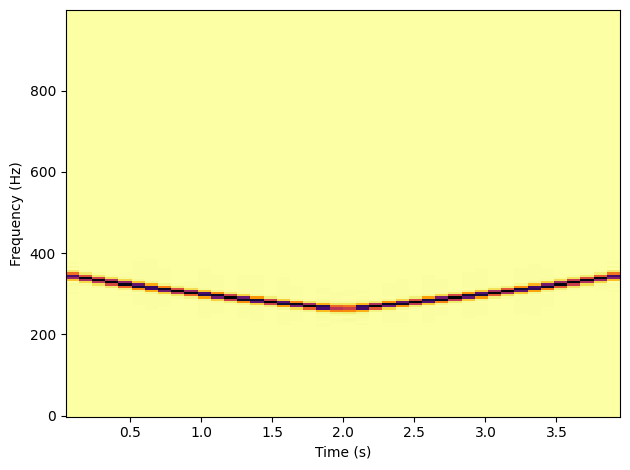

In [37]:
sppp = Trombone.make_spectrogram(2048)
sppp.plot(high=1000)
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

Глиссандо на тромбоне выглядит как экпоненциальный чирп.

# **Упражнение 3.6**
Сделайте или найдите запись серии гласных звуков и посмотрите на спектрограмму. Сможете ли вы различить разные гласные?

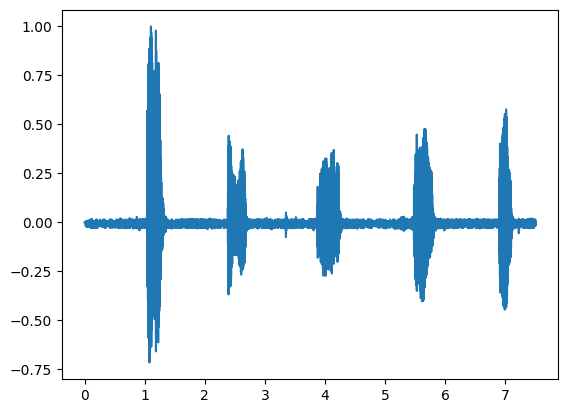

In [47]:
from thinkdsp import read_wave
filename = "vowels.wav"
vowels_wave = read_wave(filename)
start = 0
length = 7.5
vowels_segment = vowels_wave.segment(start, length)
vowels_segment.plot()

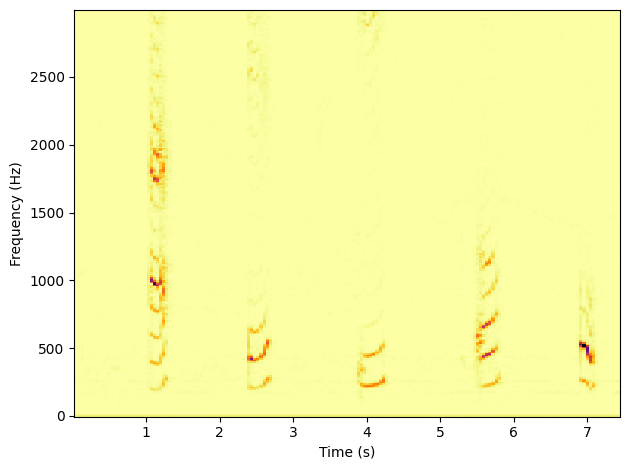

In [49]:
vowels_segment.make_spectrogram(4096).plot(high=3000)
decorate(xlabel='Time (s)', ylabel='Frequency (Hz)')

Самая высокая часота у "А", самая низкая у "И".